# 01 · Exploring the MIT-BIH Arrhythmia Database

Phase 2 of the [implementation plan](../docs/implementation-plan.md): a narrative over the
Phase 1 inventory code. This notebook characterises the source data and ends by
pre-registering the V1 preprocessing candidates.

**Scope.** Educational / research only. This is beat-morphology exploration on
expert-annotated beats, not rhythm interpretation and not clinical software.

**Decision gate.** No split and no model until this notebook has reported the
mapped V1/V2 distribution and the candidate window + filter configuration is
written to versioned config (`config/preprocessing_candidates.v1.json`).

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb

# Make `src` importable and resolve the repo root regardless of the kernel's cwd.
ROOT = Path.cwd()
while not (ROOT / "data" / "processed" / "mitdb_manifest.v1.json").is_file():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate the repository root")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data.labels import ABNORMAL, NORMAL, V2_CLASSES, map_v1, map_v2, summarize_counts

RAW_DIR = ROOT / "data" / "raw" / "mitdb-1.0.0"
MANIFEST_PATH = ROOT / "data" / "processed" / "mitdb_manifest.v1.json"
LEAD_MAP_PATH = ROOT / "config" / "lead_selection.v1.json"
CANDIDATES_PATH = ROOT / "config" / "preprocessing_candidates.v1.json"

manifest = json.loads(MANIFEST_PATH.read_text())
lead_map = json.loads(LEAD_MAP_PATH.read_text())
records = manifest["records"]
print(f"{len(records)} records · manifest built {manifest['created_at_utc']}")
print(f"source: {manifest['source']['dataset']} v{manifest['source']['version']} (DOI {manifest['source']['doi']})")

plt.rcParams["figure.figsize"] = (12, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

48 records · manifest built 2026-08-13T17:51:39.001061+00:00
source: MIT-BIH Arrhythmia Database v1.0.0 (DOI 10.13026/C2F305)


## 1 · Dataset overview

Sampling frequency, duration, channels, and the selected lead for every record.

In [2]:
overview = pd.DataFrame(
    {
        "record": r["record_id"],
        "fs_hz": r["sampling_frequency_hz"],
        "duration_s": round(r["duration_seconds"], 1),
        "samples": r["signal_length_samples"],
        "channels": ", ".join(r["channel_names"]),
        "selected_lead": r["selected_lead"]["channel_name"],
        "lead_index": r["selected_lead"]["channel_index"],
        "annotations": sum(r["annotation_counts_by_symbol"].values()),
    }
    for r in records
).set_index("record")
overview

,fs_hz,duration_s,samples,channels,selected_lead,lead_index,annotations
record,,,,,,,
100,360,1805.6,650000,"MLII, V5",MLII,0,2274
101,360,1805.6,650000,"MLII, V1",MLII,0,1874
102,360,1805.6,650000,"V5, V2",V5,0,2192
103,360,1805.6,650000,"MLII, V2",MLII,0,2091
104,360,1805.6,650000,"V5, V2",V5,0,2311
105,360,1805.6,650000,"MLII, V1",MLII,0,2691
106,360,1805.6,650000,"MLII, V1",MLII,0,2098
107,360,1805.6,650000,"MLII, V1",MLII,0,2140
108,360,1805.6,650000,"MLII, V1",MLII,0,1824


In [3]:
assert set(overview["fs_hz"]) == {360}, "expected every record at 360 Hz"
assert set(overview["channels"].str.count(",") + 1) == {2}, "expected two channels per record"
assert overview["duration_s"].between(1800, 1810).all(), "expected ~30-minute records"
print(f"All {len(overview)} records: 360 Hz, 2 channels, "
      f"{overview['duration_s'].min():.0f}-{overview['duration_s'].max():.0f} s "
      f"(~{overview['duration_s'].mean()/60:.1f} min).")
print(f"Total annotations across the database: {overview['annotations'].sum():,}")

All 48 records: 360 Hz, 2 channels, 1806-1806 s (~30.1 min).
Total annotations across the database: 112,647


In [4]:
# Lead-selection exceptions: anything that is not MLII at channel index 0.
exceptions = overview[(overview["selected_lead"] != "MLII") | (overview["lead_index"] != 0)]
exceptions.assign(rationale=[lead_map["records"][r]["rationale"] for r in exceptions.index])

,fs_hz,duration_s,samples,channels,selected_lead,lead_index,annotations,rationale
record,,,,,,,,
102,360,1805.6,650000,"V5, V2",V5,0,2192,No MLII channel is documented; select document...
104,360,1805.6,650000,"V5, V2",V5,0,2311,No MLII channel is documented; select document...
114,360,1805.6,650000,"V5, MLII",MLII,1,1890,"Documented channel order is V5, MLII; MLII is ..."


Only three records deviate from *MLII at index 0*: **102** and **104** have no MLII
lead (V5 is used), and **114** carries MLII at index 1 because its channel order is
`V5, MLII`. Everything downstream reads the lead named here, never a fixed index.

## 2 · Waveforms

Signals are read from the **selected lead only**. One full record first, then
zoomed segments.

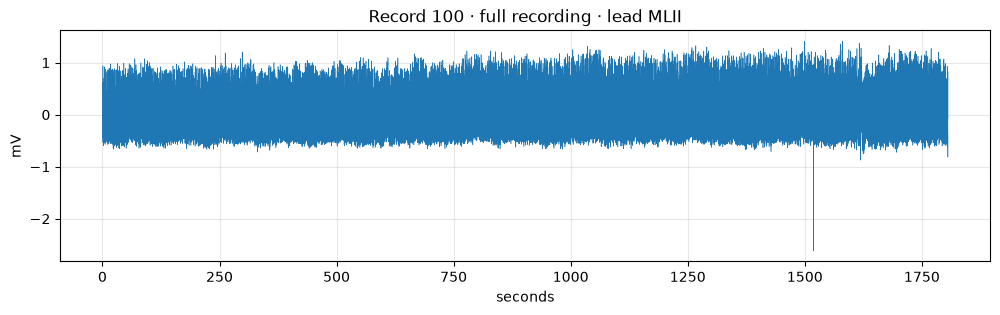

In [5]:
def selected_lead_index(record_id: str) -> int:
    return next(r for r in records if r["record_id"] == record_id)["selected_lead"]["channel_index"]

def load_lead(record_id: str):
    signal, fields = wfdb.rdsamp(str(RAW_DIR / record_id))
    idx = selected_lead_index(record_id)
    return signal[:, idx], fields["fs"], fields["sig_name"][idx]

sig, fs, name = load_lead("100")
t = np.arange(sig.size) / fs
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t[::5], sig[::5], lw=0.4)
ax.set(title=f"Record 100 · full recording · lead {name}", xlabel="seconds", ylabel="mV")
plt.show()

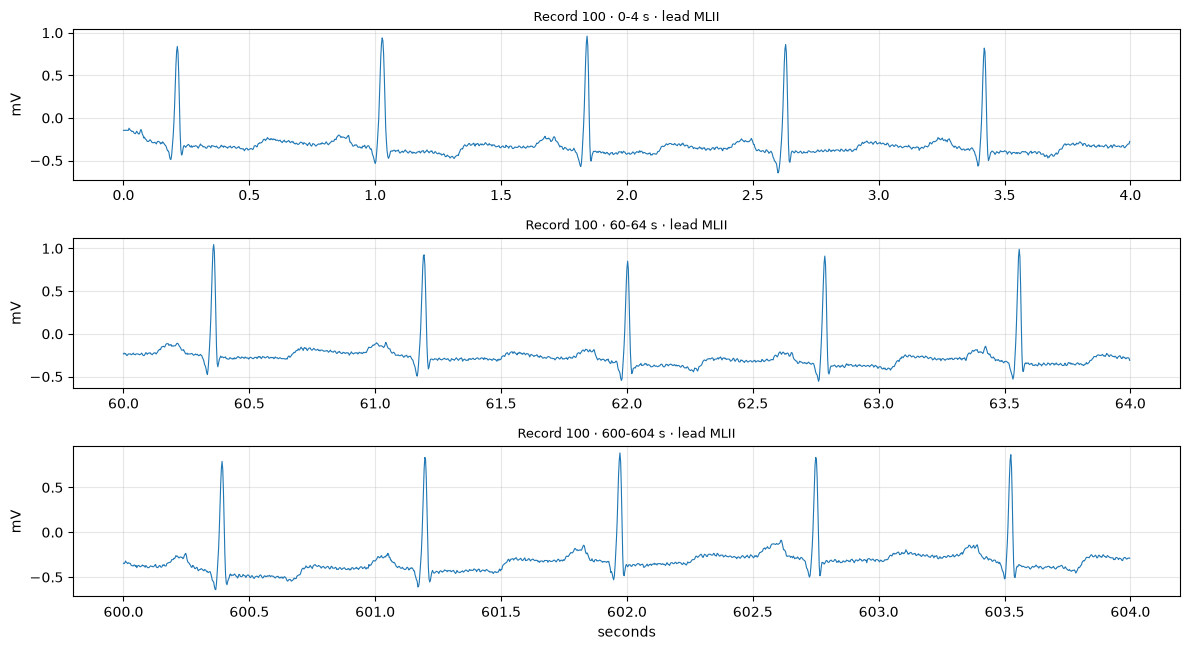

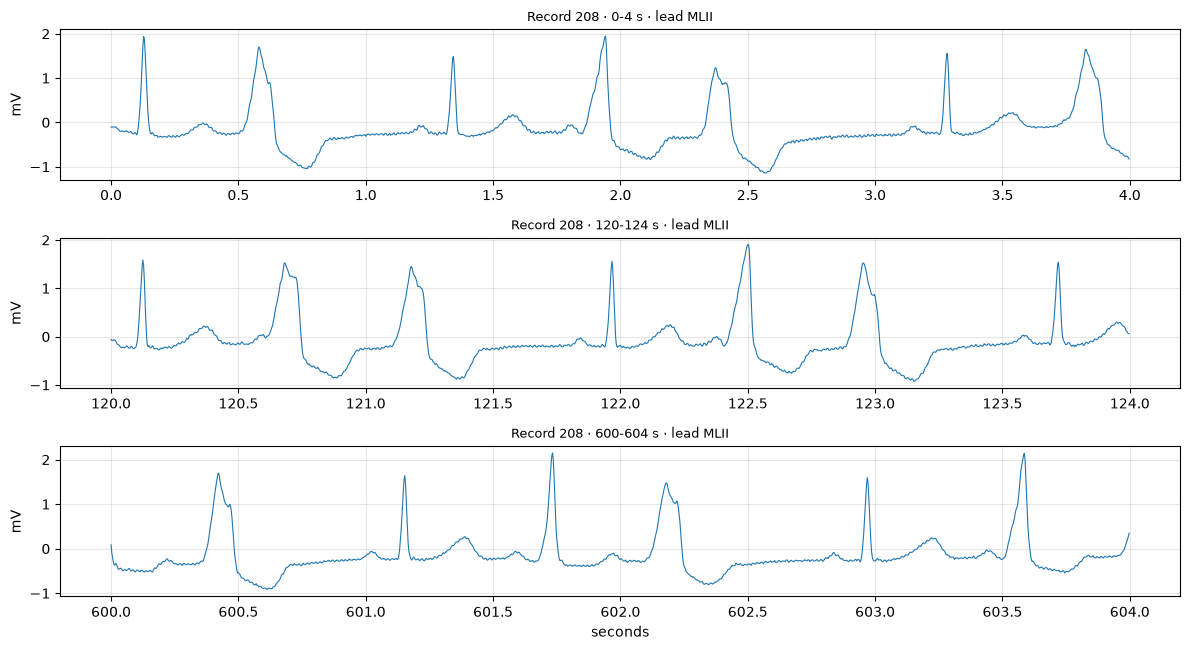

In [6]:
def plot_segments(record_id: str, starts_s, width_s=4.0):
    sig, fs, name = load_lead(record_id)
    fig, axes = plt.subplots(len(starts_s), 1, figsize=(12, 2.2 * len(starts_s)), squeeze=False)
    for ax, start in zip(axes[:, 0], starts_s):
        a, b = int(start * fs), int((start + width_s) * fs)
        ax.plot(np.arange(a, b) / fs, sig[a:b], lw=0.8)
        ax.set(ylabel="mV")
        ax.set_title(f"Record {record_id} · {start:.0f}-{start + width_s:.0f} s · lead {name}", fontsize=9)
    axes[-1, 0].set_xlabel("seconds")
    fig.tight_layout()
    plt.show()

plot_segments("100", [0, 60, 600])   # calm, predominantly normal
plot_segments("208", [0, 120, 600])  # frequent ventricular ectopy

## 3 · Expert annotation overlay

Beat annotations mark the R-peak sample and a symbol. Overlaying them shows what
the model will be asked to classify.

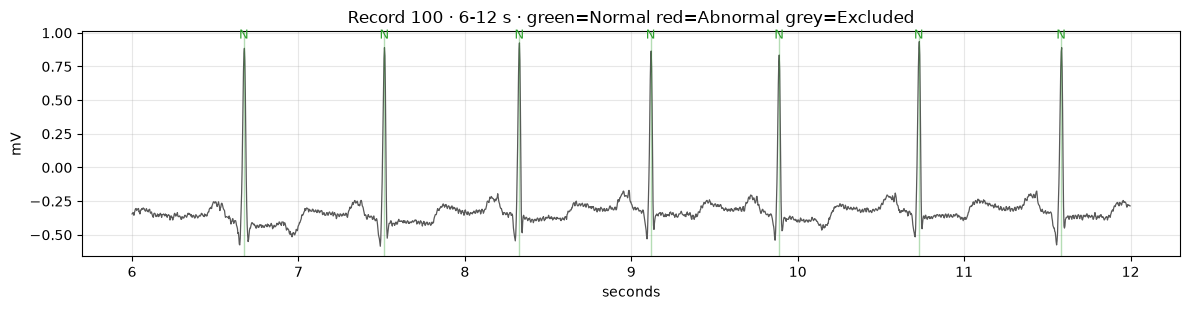

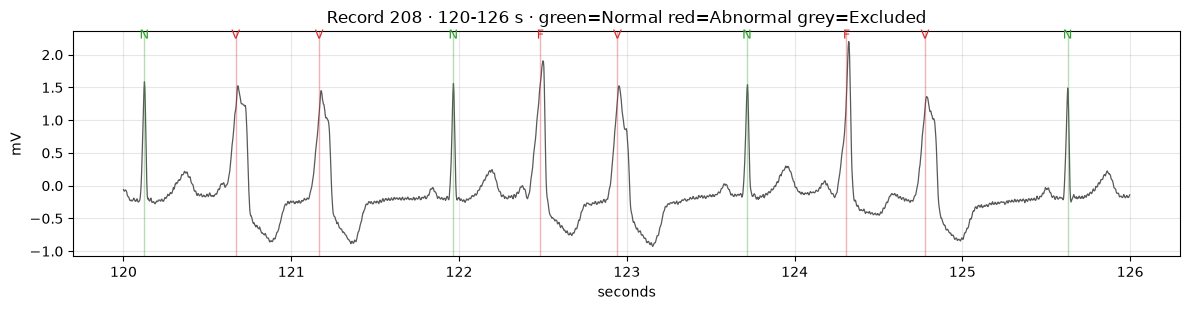

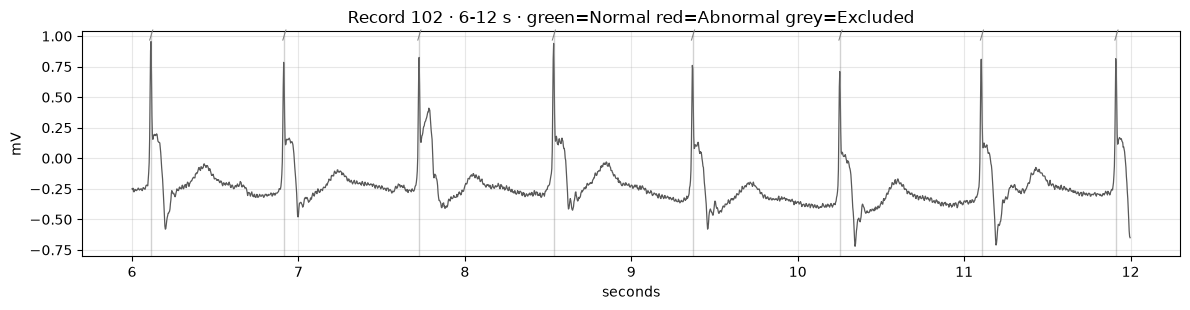

In [7]:
def load_annotations(record_id: str):
    ann = wfdb.rdann(str(RAW_DIR / record_id), "atr")
    return np.asarray(ann.sample), list(ann.symbol)

def plot_annotated(record_id: str, start_s: float, width_s: float = 6.0):
    sig, fs, name = load_lead(record_id)
    samples, symbols = load_annotations(record_id)
    a, b = int(start_s * fs), int((start_s + width_s) * fs)
    fig, ax = plt.subplots(figsize=(12, 3.2))
    ax.plot(np.arange(a, b) / fs, sig[a:b], lw=0.9, color="0.35")
    y = sig[a:b].max()
    for s, sym in zip(samples, symbols):
        if a <= s < b:
            v1 = map_v1(sym)
            color = {"Normal": "tab:green", "Abnormal": "tab:red"}.get(v1, "tab:gray")
            ax.axvline(s / fs, color=color, alpha=0.35, lw=1)
            ax.text(s / fs, y, sym, ha="center", va="bottom", fontsize=9, color=color)
    ax.set(title=f"Record {record_id} · {start_s:.0f}-{start_s + width_s:.0f} s · "
                 f"green=Normal red=Abnormal grey=Excluded",
           xlabel="seconds", ylabel="mV")
    fig.tight_layout()
    plt.show()

plot_annotated("100", 6)     # N beats plus an A (atrial premature)
plot_annotated("208", 120)   # V and F beats
plot_annotated("102", 6)     # paced record: "/" beats, all Excluded from V1

## 4 · Raw annotation-symbol inventory

Pooled across all 48 records, straight from the manifest (no WFDB re-read).

In [8]:
SYMBOL_MEANING = {
    "N": "Normal beat", "L": "LBBB beat", "R": "RBBB beat", "e": "Atrial escape",
    "j": "Nodal (junctional) escape", "A": "Atrial premature", "a": "Aberrated atrial premature",
    "J": "Nodal premature", "S": "Supraventricular premature", "V": "Premature ventricular contraction",
    "E": "Ventricular escape", "F": "Fusion of ventricular and normal", "/": "Paced beat",
    "f": "Fusion of paced and normal", "Q": "Unclassifiable beat", "+": "Rhythm change (non-beat)",
    "~": "Signal-quality change (non-beat)", "|": "Isolated QRS-like artifact (non-beat)",
    "!": "Ventricular flutter wave (non-beat)", '"': "Comment annotation (non-beat)",
    "x": "Non-conducted P-wave (non-beat)", "[": "Start of ventricular flutter/fibrillation",
    "]": "End of ventricular flutter/fibrillation",
}

pooled = Counter()
for r in records:
    pooled.update(r["annotation_counts_by_symbol"])

symbol_table = pd.DataFrame(
    {"symbol": s, "count": c,
     "v1": map_v1(s) or "-", "v2": map_v2(s) or "-",
     "meaning": SYMBOL_MEANING.get(s, "?")}
    for s, c in pooled.most_common()
).set_index("symbol")
symbol_table

,count,v1,v2,meaning
symbol,,,,
N,75052,Normal,N,Normal beat
L,8075,Normal,N,LBBB beat
R,7259,Normal,N,RBBB beat
V,7130,Abnormal,V,Premature ventricular contraction
/,7028,-,Q,Paced beat
A,2546,Abnormal,S,Atrial premature
+,1291,-,-,Rhythm change (non-beat)
f,982,-,Q,Fusion of paced and normal
F,803,Abnormal,F,Fusion of ventricular and normal


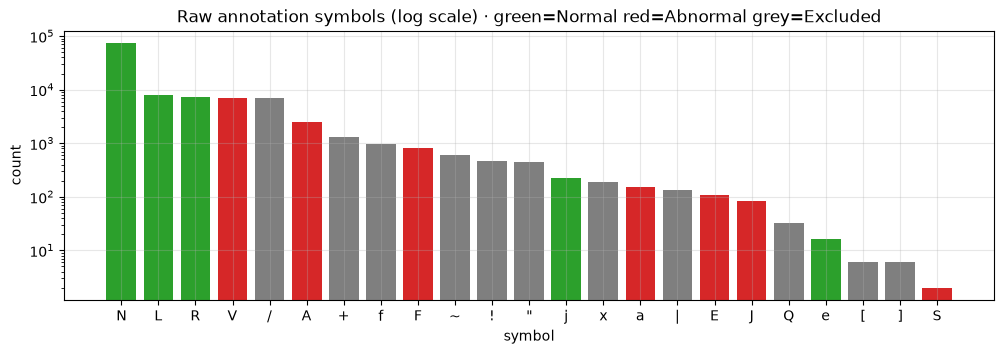

In [9]:
fig, ax = plt.subplots(figsize=(12, 3.5))
order = [s for s, _ in pooled.most_common()]
colors = ["tab:green" if map_v1(s) == NORMAL else "tab:red" if map_v1(s) == ABNORMAL else "tab:gray"
          for s in order]
ax.bar(range(len(order)), [pooled[s] for s in order], color=colors)
ax.set_yscale("log")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set(title="Raw annotation symbols (log scale) · green=Normal red=Abnormal grey=Excluded",
       ylabel="count", xlabel="symbol")
plt.show()

## 5 · Mapped V1 and V2 class distributions

The gate deliverable. V1 is the binary target; V2 is the five-class superclass
mapping. Note the imbalance.

In [10]:
summary = summarize_counts(pooled)

v1_total = summary["v1_included_total"]
print("V1 (binary) — included beats:", f"{v1_total:,}")
for k, v in summary["v1"].items():
    print(f"  {k:<9} {v:>8,}  ({v / v1_total:6.2%})")
print()
v2_total = summary["v2_included_total"]
print("V2 (five-class) — included beats:", f"{v2_total:,}")
for k in V2_CLASSES:
    v = summary["v2"][k]
    print(f"  {k:<9} {v:>8,}  ({v / v2_total:6.2%})")
print()
print(f"Excluded from V1: {summary['excluded_total']:,} annotations "
      f"({len(summary['excluded_by_symbol'])} distinct symbols); "
      f"V2 recovers {summary['v2_recovered_total']:,} of them as class Q.")

V1 (binary) — included beats: 101,451
  Normal      90,631  (89.33%)
  Abnormal    10,820  (10.67%)

V2 (five-class) — included beats: 109,494
  N           90,631  (82.77%)
  S            2,781  ( 2.54%)
  V            7,236  ( 6.61%)
  F              803  ( 0.73%)
  Q            8,043  ( 7.35%)

Excluded from V1: 11,196 annotations (11 distinct symbols); V2 recovers 8,043 of them as class Q.


In [11]:
# Per-record V1 breakdown.
rows = []
for r in records:
    s = summarize_counts(r["annotation_counts_by_symbol"])
    inc = s["v1_included_total"]
    rows.append({
        "record": r["record_id"],
        "Normal": s["v1"][NORMAL],
        "Abnormal": s["v1"][ABNORMAL],
        "Excluded": s["excluded_total"],
        "included": inc,
        "abnormal_%": round(100 * s["v1"][ABNORMAL] / inc, 1) if inc else 0.0,
    })
per_record_v1 = pd.DataFrame(rows).set_index("record")
per_record_v1

,Normal,Abnormal,Excluded,included,abnormal_%
record,,,,,
100,2239,34,1,2273,1.5
101,1860,3,11,1863,0.2
102,99,4,2089,103,3.9
103,2082,2,7,2084,0.1
104,163,2,2146,165,1.2
105,2526,41,124,2567,1.6
106,1507,520,71,2027,25.7
107,0,59,2081,59,100.0
108,1740,23,61,1763,1.3


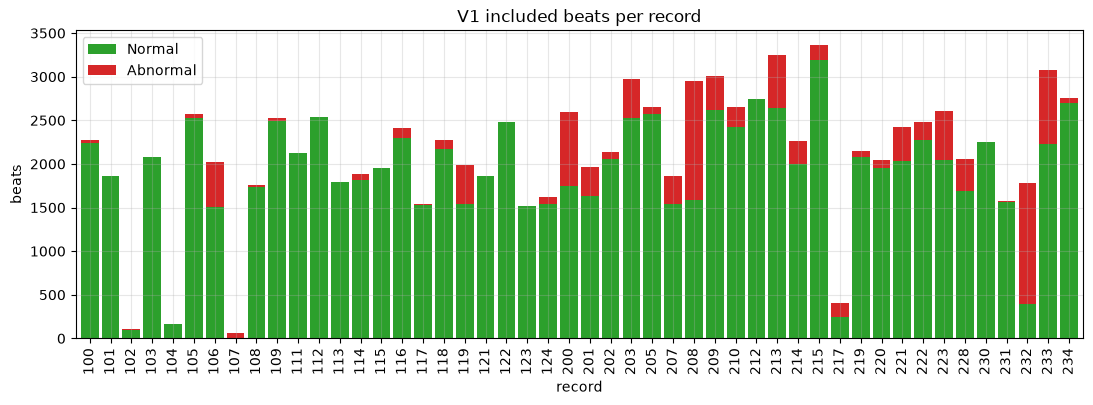

Records with the most abnormal beats:
        Normal  Abnormal  abnormal_%
record                              
232        398      1382        77.6
208       1586      1367        46.3
200       1743       858        33.0
233       2230       849        27.6
213       2641       610        18.8
223       2045       560        21.5
106       1507       520        25.7
203       2529       447        15.0

Records with zero abnormal beats: 115, 122, 212


In [12]:
ax = per_record_v1[["Normal", "Abnormal"]].plot(
    kind="bar", stacked=True, figsize=(13, 4), color=["tab:green", "tab:red"], width=0.85
)
ax.set(title="V1 included beats per record", ylabel="beats", xlabel="record")
plt.show()

print("Records with the most abnormal beats:")
print(per_record_v1.sort_values("Abnormal", ascending=False).head(8)[["Normal", "Abnormal", "abnormal_%"]])
print("\nRecords with zero abnormal beats:",
      ", ".join(per_record_v1[per_record_v1["Abnormal"] == 0].index))

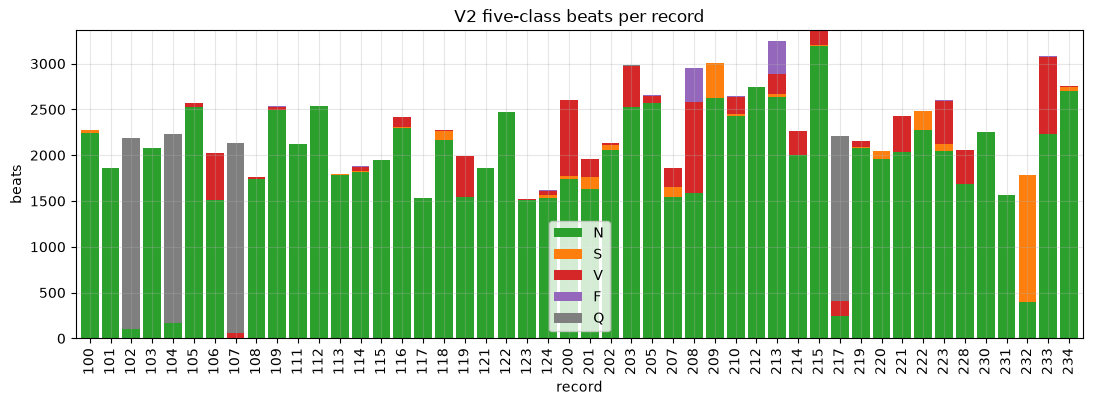

,N,S,V,F,Q
pooled,90631,2781,7236,803,8043


In [13]:
# Per-record V2 breakdown.
v2_rows = []
for r in records:
    s = summarize_counts(r["annotation_counts_by_symbol"])
    v2_rows.append({"record": r["record_id"], **s["v2"]})
per_record_v2 = pd.DataFrame(v2_rows).set_index("record")

ax = per_record_v2.plot(kind="bar", stacked=True, figsize=(13, 4), width=0.85,
                        color=["tab:green", "tab:orange", "tab:red", "tab:purple", "tab:gray"])
ax.set(title="V2 five-class beats per record", ylabel="beats", xlabel="record")
plt.show()
per_record_v2.sum().rename("pooled").to_frame().T

## 6 · Excluded annotations

Excluded = outside the V1 mapping: paced (`/`), fusion-paced (`f`), unclassifiable
(`Q`), and every non-beat / rhythm / quality marker. Excluding these does **not**
drop the whole record — valid mapped beats in the same record are still used.

In [14]:
excluded_table = pd.DataFrame(
    {"symbol": s, "count": c, "meaning": SYMBOL_MEANING.get(s, "?"),
     "recovered_by_v2": map_v2(s) or "-"}
    for s, c in sorted(summary["excluded_by_symbol"].items(), key=lambda kv: -kv[1])
).set_index("symbol")
display(excluded_table)

paced = [(r["record_id"], r["annotation_counts_by_symbol"].get("/", 0),
          summarize_counts(r["annotation_counts_by_symbol"])["v1_included_total"])
         for r in records if r["annotation_counts_by_symbol"].get("/", 0) > 0]
print("Paced-beat records (/ count, and V1-included beats they still contribute):")
for rid, n_paced, inc in sorted(paced, key=lambda x: -x[1]):
    print(f"  record {rid}: {n_paced:>5,} paced   {inc:>5,} still included")

,count,meaning,recovered_by_v2
symbol,,,
/,7028,Paced beat,Q
+,1291,Rhythm change (non-beat),-
f,982,Fusion of paced and normal,Q
~,616,Signal-quality change (non-beat),-
!,472,Ventricular flutter wave (non-beat),-
"""",437,Comment annotation (non-beat),-
x,193,Non-conducted P-wave (non-beat),-
|,132,Isolated QRS-like artifact (non-beat),-
Q,33,Unclassifiable beat,Q


Paced-beat records (/ count, and V1-included beats they still contribute):
  record 107: 2,078 paced      59 still included
  record 102: 2,028 paced     103 still included
  record 217: 1,542 paced     406 still included
  record 104: 1,380 paced     165 still included


## 7 · Lead availability

Restated from `config/lead_selection.v1.json`: MLII wherever documented, with the
three exceptions from section 1.

In [15]:
lead_summary = Counter(r["selected_lead"]["channel_name"] for r in records)
print("Selected lead across records:", dict(lead_summary))
print("Non-MLII / non-index-0 records:", ", ".join(exceptions.index))

Selected lead across records: {'MLII': 46, 'V5': 2}
Non-MLII / non-index-0 records: 102, 104, 114


## 8 · Window-edge feasibility

For each candidate window, count the **V1-included** beats whose window would run
past the start or end of its recording. These annotations will be skipped and
reported, per the plan.

In [16]:
candidates = json.loads(CANDIDATES_PATH.read_text())

edge_rows = []
for w in candidates["windows"]:
    pre, post = w["pre_samples"], w["post_samples"]
    total_skipped = 0
    per_record_skips = {}
    total_included = 0
    for r in records:
        rid = r["record_id"]
        sig_len = r["signal_length_samples"]
        samples, symbols = load_annotations(rid)
        included = np.array([map_v1(sym) is not None for sym in symbols])
        s = samples[included]
        total_included += s.size
        bad = int(np.sum((s - pre < 0) | (s + post > sig_len)))
        if bad:
            per_record_skips[rid] = bad
        total_skipped += bad
    edge_rows.append({
        "window": w["id"],
        "pre/post samples": f"{pre}/{post}",
        "total_s": w["total_seconds"],
        "skipped_beats": total_skipped,
        "skipped_%": round(100 * total_skipped / total_included, 4),
        "records_affected": ", ".join(f"{k}:{v}" for k, v in per_record_skips.items()) or "-",
    })
pd.DataFrame(edge_rows).set_index("window")

,pre/post samples,total_s,skipped_beats,skipped_%,records_affected
window,,,,,
w-small,72/144,0.6,33,0.0325,"100:1, 103:1, 109:1, 112:1, 113:1, 115:1, 116:..."
w-mid,90/162,0.7,39,0.0384,"100:2, 101:1, 103:1, 108:1, 109:1, 112:1, 113:..."
w-wide,108/216,0.9,49,0.0483,"100:2, 101:1, 103:1, 106:1, 108:1, 109:1, 112:..."


Only the first / last beats of a record can fall outside its bounds, so the loss
is a handful of beats out of ~110k. No candidate is disqualified on edge effects.

## 9 · Signal-quality concerns

Records carrying many non-beat quality markers (`~`, `|`, `x`, `!`) are the ones
with noisy stretches. Reported here, plotted for one case.

,quality_markers,total_annotations,fraction_%
record,,,
207,489,2385,20.50
231,429,2011,21.33
219,137,2312,5.93
105,118,2691,4.38
203,83,3108,2.67
108,60,1824,3.29
228,47,2141,2.20
200,43,2792,1.54
201,41,2039,2.01


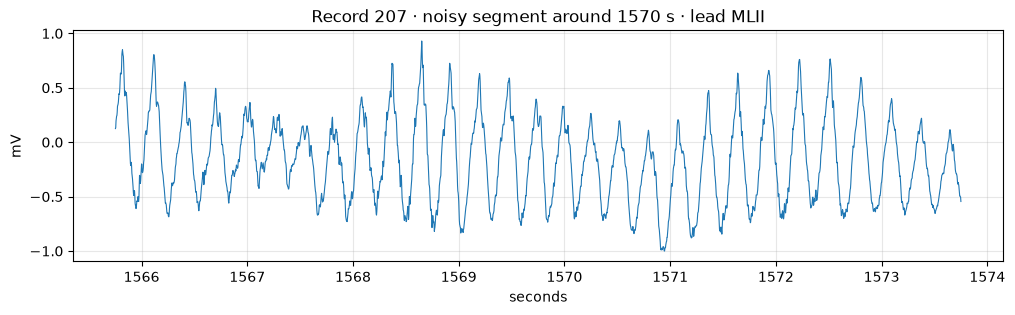

In [17]:
QUALITY_MARKERS = ["~", "|", "x", "!", '"']
q_rows = []
for r in records:
    counts = r["annotation_counts_by_symbol"]
    total = sum(counts.values())
    noisy = sum(counts.get(m, 0) for m in QUALITY_MARKERS)
    q_rows.append({"record": r["record_id"], "quality_markers": noisy,
                   "total_annotations": total, "fraction_%": round(100 * noisy / total, 2)})
quality = pd.DataFrame(q_rows).set_index("record").sort_values("quality_markers", ascending=False)
display(quality.head(12))

worst = quality.index[0]
sig, fs, nm = load_lead(worst)
# find the densest 8-second run of quality markers
samples, symbols = load_annotations(worst)
qs = np.array([s for s, sym in zip(samples, symbols) if sym in QUALITY_MARKERS])
center = int(np.median(qs)) if qs.size else sig.size // 2
a, b = max(0, center - 4 * fs), min(sig.size, center + 4 * fs)
plt.figure(figsize=(12, 3))
plt.plot(np.arange(a, b) / fs, sig[a:b], lw=0.8)
plt.title(f"Record {worst} · noisy segment around {center / fs:.0f} s · lead {nm}")
plt.xlabel("seconds"); plt.ylabel("mV")
plt.show()

## 10 · Decision — pre-registered V1 preprocessing candidates

Written to `config/preprocessing_candidates.v1.json` and committed. Three
asymmetric windows (more post-R than pre-R) and one band-pass filter. Window,
filter, and normalisation choices are **validation-only** experiments; nothing
here is a final choice.

In [18]:
print(json.dumps(candidates, indent=2))

for w in candidates["windows"]:
    assert w["post_samples"] > w["pre_samples"], f"{w['id']} is not asymmetric post>pre"
    assert w["pre_samples"] + w["post_samples"] == w["total_samples"]
f = candidates["filter"]
assert f["low_cut_hz"] < f["high_cut_hz"] < candidates["sampling_frequency_hz"] / 2
print("\nAll candidate windows asymmetric (post > pre); filter band within Nyquist. Gate satisfied.")

{
  "schema_version": 1,
  "config_version": "preprocessing-candidates.v1",
  "dataset": {
    "id": "mitdb",
    "version": "1.0.0"
  },
  "sampling_frequency_hz": 360,
  "selected_after": "notebooks/01_exploring_ecg.ipynb",
  "notes": "Pre-registered V1 candidates chosen after Phase 2 data exploration. Each window is asymmetric with more post-R than pre-R waveform. Window choice, filtering, and per-window normalization are validation-only experiments (implementation-plan.md Phase 2, ADR 0005).",
  "windows": [
    {
      "id": "w-small",
      "pre_samples": 72,
      "post_samples": 144,
      "total_samples": 216,
      "pre_seconds": 0.2,
      "post_seconds": 0.4,
      "total_seconds": 0.6,
      "rationale": "Tight QRS-centred window. Minimal neighbour-beat contamination at fast rates; may clip late T-wave morphology used to separate F and V beats."
    },
    {
      "id": "w-mid",
      "pre_samples": 90,
      "post_samples": 162,
      "total_samples": 252,
      "pre_seco

## Gate status

- Mapped V1 distribution reported: **Normal vs Abnormal**, pooled and per record (section 5).
- Mapped V2 five-class distribution reported (section 5).
- Raw symbols, excluded annotations, lead availability, window-edge skips, and
  signal-quality notes reported (sections 4, 6-9).
- Candidate windows + filter written to versioned config and validated (section 10).

**Next:** Phase 3 — build the deterministic dataset contract (label mapping,
window extraction, training-only normalisation, and the one fixed
participant-grouped split) under `src/`, with leakage tests.